# Porto Taxi Trajectory (ECML/PKDD 2015) — EDA
Following `docs/eda_checklist.md`.

No rider ID (this is dispatch/trip data, not per-passenger). Rec-context (#10) reframed as `TAXI_ID` (driver) x `ORIGIN_STAND` (taxi stand) — which stands each driver works from.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

DATA_PATH = "../../data/raw/ride/porto_taxi/train.csv"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
trips = pd.read_csv(DATA_PATH)
print(trips.shape)
trips.head()

(1710670, 9)


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."


In [3]:
trips.dtypes

TRIP_ID           int64
CALL_TYPE           str
ORIGIN_CALL     float64
ORIGIN_STAND    float64
TAXI_ID           int64
TIMESTAMP         int64
DAY_TYPE            str
MISSING_DATA       bool
POLYLINE            str
dtype: object

In [4]:
# n_points from POLYLINE string without full JSON parse (cheap, vectorized): outer '[' + one per point
trips["n_points"] = trips["POLYLINE"].str.count(r"\[") - 1
trips["trip_duration_sec"] = (trips["n_points"] - 1).clip(lower=0) * 15
trips[["n_points", "trip_duration_sec"]].describe()

,n_points,trip_duration_sec
count,1.710670e+06,1.710670e+06
mean,4.875831e+01,7.164265e+02
std,4.565372e+01,6.847512e+02
min,0.000000e+00,0.000000e+00
25%,2.800000e+01,4.050000e+02
50%,4.100000e+01,6.000000e+02
75%,5.900000e+01,8.700000e+02
max,3.881000e+03,5.820000e+04


## 2. Missing Values

In [5]:
(trips.isna().mean() * 100).round(1).sort_values(ascending=False)

ORIGIN_CALL          78.7
ORIGIN_STAND         52.9
TRIP_ID               0.0
CALL_TYPE             0.0
TAXI_ID               0.0
TIMESTAMP             0.0
DAY_TYPE              0.0
MISSING_DATA          0.0
POLYLINE              0.0
n_points              0.0
trip_duration_sec     0.0
dtype: float64

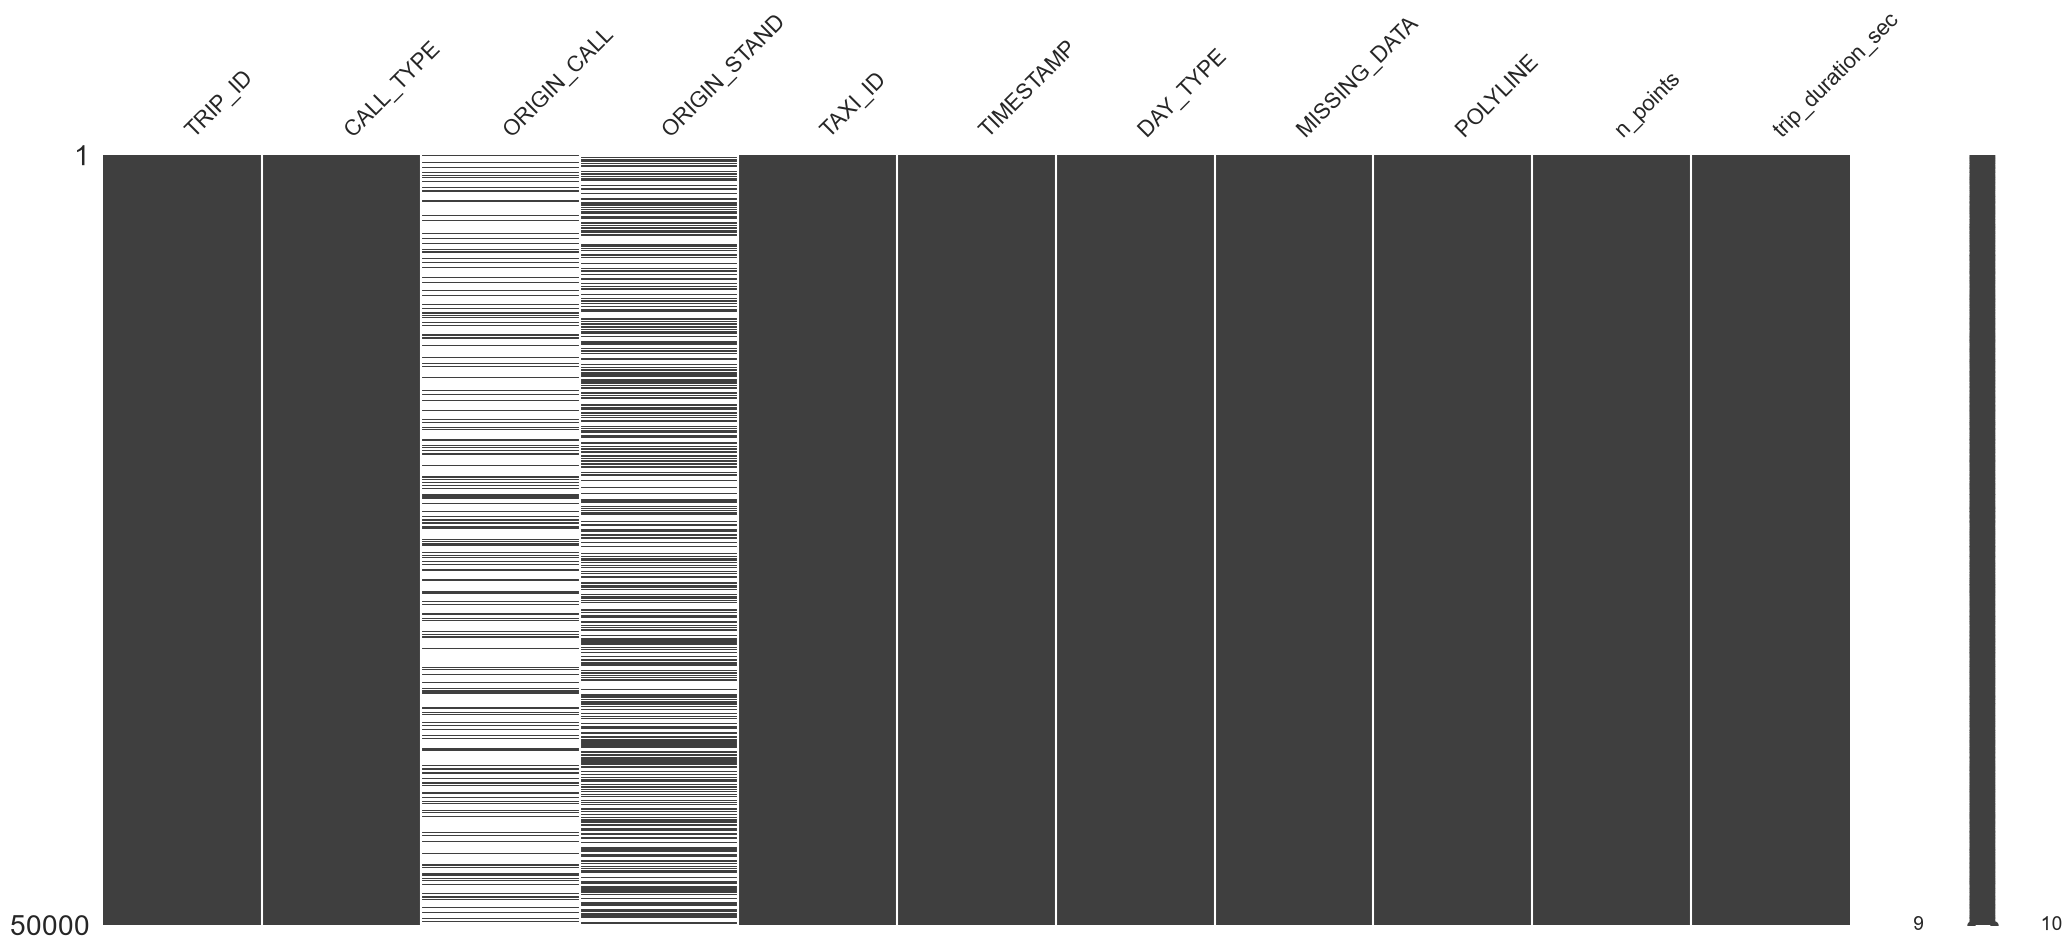

In [6]:
msno.matrix(trips.sample(50_000, random_state=0)); plt.show()

Decision: `ORIGIN_CALL` fully aligned with `CALL_TYPE == 'A'` (verify in section 9). `ORIGIN_STAND` mostly aligned with `CALL_TYPE == 'B'` but not perfectly — some B-type rows still missing stand id, check exact count in section 9.

## 3. Duplicates

In [7]:
print("full-row dup:", trips.duplicated().sum())
print("dup TRIP_ID:", trips.duplicated(subset=["TRIP_ID"]).sum())

full-row dup: 3
dup TRIP_ID: 81


## 4. Univariate Analysis

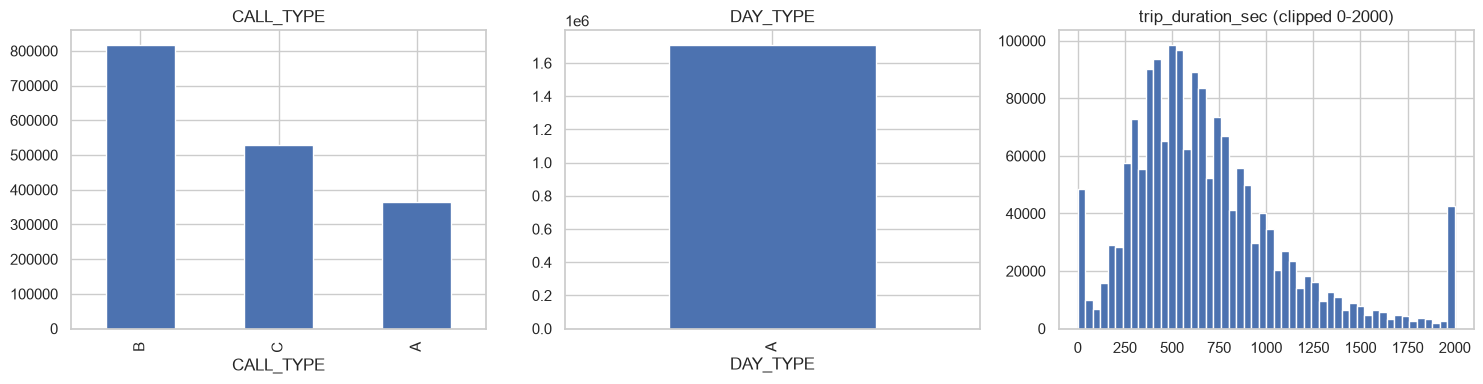

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
trips["CALL_TYPE"].value_counts().plot(kind="bar", ax=ax[0]); ax[0].set_title("CALL_TYPE")
trips["DAY_TYPE"].value_counts().plot(kind="bar", ax=ax[1]); ax[1].set_title("DAY_TYPE")
trips["trip_duration_sec"].clip(0, 2000).hist(bins=50, ax=ax[2]); ax[2].set_title("trip_duration_sec (clipped 0-2000)")
plt.tight_layout(); plt.show()

In [9]:
print("unique TAXI_ID:", trips["TAXI_ID"].nunique())
trips.groupby("TAXI_ID").size().describe()

unique TAXI_ID: 448


count      448.000000
mean      3818.459821
std       1644.021173
min          1.000000
25%       2694.000000
50%       3732.000000
75%       5023.250000
max      10746.000000
dtype: float64

## 5. Outliers

MISSING_DATA == True: 10
empty POLYLINE (n_points==0): 5901
trip_duration_sec == 0 but MISSING_DATA==False: 36508
trip_duration_sec > 3h: 847


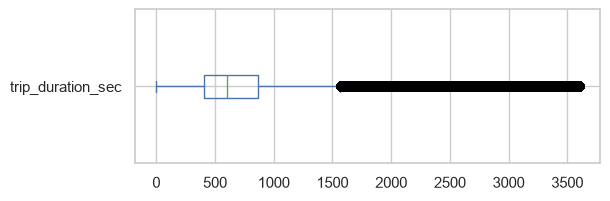

In [10]:
print("MISSING_DATA == True:", trips["MISSING_DATA"].sum())
print("empty POLYLINE (n_points==0):", (trips["n_points"] == 0).sum())
print("trip_duration_sec == 0 but MISSING_DATA==False:", ((trips["trip_duration_sec"] == 0) & ~trips["MISSING_DATA"]).sum())
print("trip_duration_sec > 3h:", (trips["trip_duration_sec"] > 3*3600).sum())
trips["trip_duration_sec"].clip(0, 3600).plot(kind="box", vert=False, figsize=(6, 2)); plt.show()

Result: `MISSING_DATA == True` only flags 10 rows, but empty `POLYLINE` (n_points==0) is actually 5,901 rows, and zero-duration trips not caught by the flag total 36,508 — the `MISSING_DATA` column badly under-reports real gaps. Filter on `n_points`/`trip_duration_sec` directly, don't trust the flag alone.

## 6. Target Variable
No target column. Original challenge defines two derived tasks: **destination** (last coordinate of `POLYLINE`) and **trip duration** (`n_points`-based, as computed above). Both constructed from `POLYLINE`, not a given label.

## 7. Bivariate / Correlation Analysis

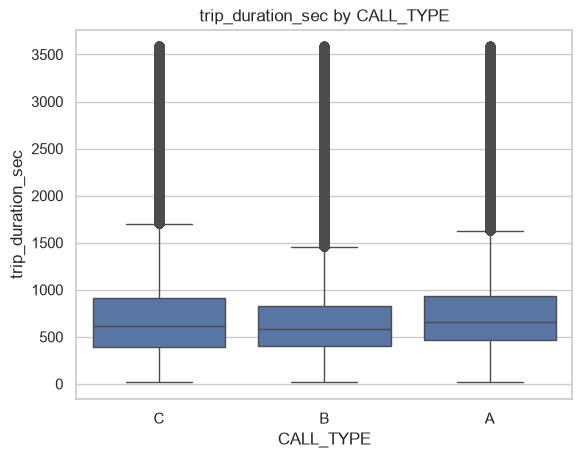

In [11]:
clean = trips[~trips["MISSING_DATA"] & (trips["trip_duration_sec"] > 0) & (trips["trip_duration_sec"] < 3600)]
sns.boxplot(x=clean["CALL_TYPE"], y=clean["trip_duration_sec"])
plt.title("trip_duration_sec by CALL_TYPE"); plt.show()

## 8. Time-based Checks

pickup range: 2013-07-01 00:00:53 to 2014-06-30 23:59:56
unique DAY_TYPE values: <ArrowStringArray>
['A']
Length: 1, dtype: str


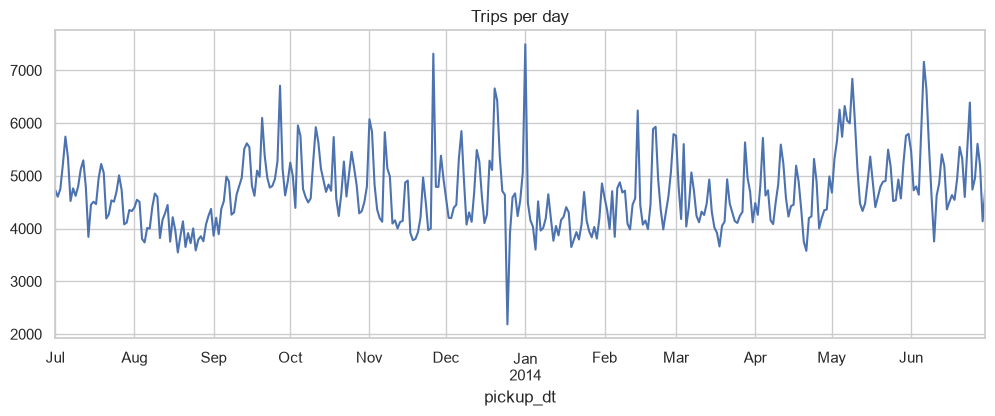

In [12]:
trips["pickup_dt"] = pd.to_datetime(trips["TIMESTAMP"], unit="s")
print("pickup range:", trips["pickup_dt"].min(), "to", trips["pickup_dt"].max())
print("unique DAY_TYPE values:", trips["DAY_TYPE"].unique())
trips.set_index("pickup_dt").resample("D").size().plot(figsize=(12, 4), title="Trips per day")
plt.show()

## 9. Data Consistency

In [13]:
print("CALL_TYPE=A but ORIGIN_CALL missing:", ((trips["CALL_TYPE"] == "A") & trips["ORIGIN_CALL"].isna()).sum())
print("CALL_TYPE!=A but ORIGIN_CALL present:", ((trips["CALL_TYPE"] != "A") & trips["ORIGIN_CALL"].notna()).sum())
print("CALL_TYPE=B but ORIGIN_STAND missing:", ((trips["CALL_TYPE"] == "B") & trips["ORIGIN_STAND"].isna()).sum())
print("CALL_TYPE!=B but ORIGIN_STAND present:", ((trips["CALL_TYPE"] != "B") & trips["ORIGIN_STAND"].notna()).sum())

CALL_TYPE=A but ORIGIN_CALL missing: 0
CALL_TYPE!=A but ORIGIN_CALL present: 0
CALL_TYPE=B but ORIGIN_STAND missing: 11302
CALL_TYPE!=B but ORIGIN_STAND present: 0


In [14]:
# Porto bounding box roughly lon -8.75 to -8.55, lat 41.05 to 41.25
first_point = trips.loc[trips["n_points"] > 0, "POLYLINE"].str.extract(r"\[\[(-?\d+\.\d+),(-?\d+\.\d+)\]").astype(float)
first_point.columns = ["lon", "lat"]
bad_coord = ~first_point["lon"].between(-8.75, -8.55) | ~first_point["lat"].between(41.05, 41.25)
print("pickup points outside Porto bbox:", bad_coord.sum(), f"({bad_coord.mean():.2%})")

pickup points outside Porto bbox: 5265 (0.31%)


## 10. Feature Relationships for Recommendation Context
Reframed: `TAXI_ID` (driver) x `ORIGIN_STAND` (taxi stand), `CALL_TYPE == 'B'` only — which stands each driver actually works from.

In [15]:
stand_trips = trips[trips["CALL_TYPE"] == "B"].dropna(subset=["ORIGIN_STAND"])
n_taxis = stand_trips["TAXI_ID"].nunique()
n_stands = stand_trips["ORIGIN_STAND"].nunique()
n_pairs = stand_trips.drop_duplicates(subset=["TAXI_ID", "ORIGIN_STAND"]).shape[0]
sparsity = 1 - n_pairs / (n_taxis * n_stands)
print(f"taxis={n_taxis} stands={n_stands} pairs={n_pairs} sparsity={sparsity:.4%}")

taxis=439 stands=63 pairs=20811 sparsity=24.7532%


stands with <=5 trips: 0 (0.0%)


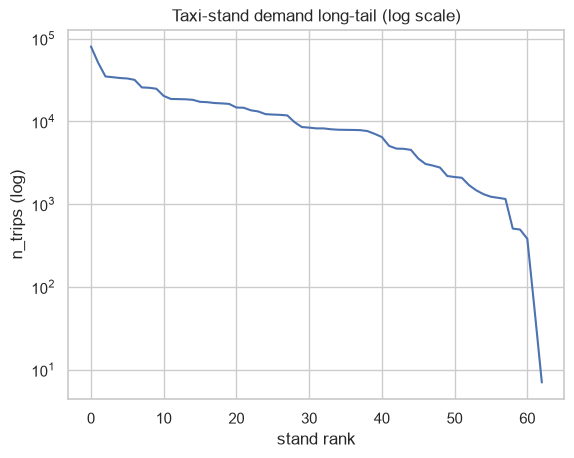

In [16]:
stand_counts = stand_trips.groupby("ORIGIN_STAND").size().sort_values(ascending=False)
cold_stands = (stand_counts <= 5).sum()
print("stands with <=5 trips:", cold_stands, f"({cold_stands/n_stands:.1%})")
stand_counts.reset_index(drop=True).plot(logy=True, title="Taxi-stand demand long-tail (log scale)")
plt.xlabel("stand rank"); plt.ylabel("n_trips (log)"); plt.show()

## 11. Summary

- Shape: 1,710,670 trips, 9 raw columns (+ derived `n_points`, `trip_duration_sec`).
- Missing `ORIGIN_CALL` (78.7%) fully structural — perfectly aligned with `CALL_TYPE != 'A'`. `ORIGIN_STAND` (52.9%) mostly structural but not perfect: 11,302 `CALL_TYPE == 'B'` rows still missing `ORIGIN_STAND` — real gap, not pure design.
- Real duplicates found: 3 full-row dup, 81 duplicate `TRIP_ID` — needs dedup before modeling.
- `MISSING_DATA` flag is unreliable: only 10 rows flagged True, but 5,901 rows have empty `POLYLINE` and 36,508 rows have zero trip duration without being flagged — filter on `n_points`/`trip_duration_sec` directly instead of trusting the flag.
- No rider ID exists — this is driver/dispatch data. Reframed rec-context (#10) as driver x taxi-stand affinity instead of user-item: 439 taxis, 63 stands, sparsity 24.75% (much denser than other datasets — small stand pool, most drivers touch most stands). 0% stands are cold (all get >5 trips).
- `DAY_TYPE` is a constant single value (`'A'`) across all rows — zero information, drop as feature.
- GPS quality good: only 0.31% of pickup points fall outside the real Porto bounding box (unlike Akeed's fully-synthetic coordinates) — this dataset's location data is genuine.
- No given target; duration and destination are both derived from `POLYLINE` itself, need feature engineering before any modeling, not just column selection.